# Importing Libraries

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

import joblib
print("Success")

Success


# Load Dataset

In [8]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


# Visualising Data 

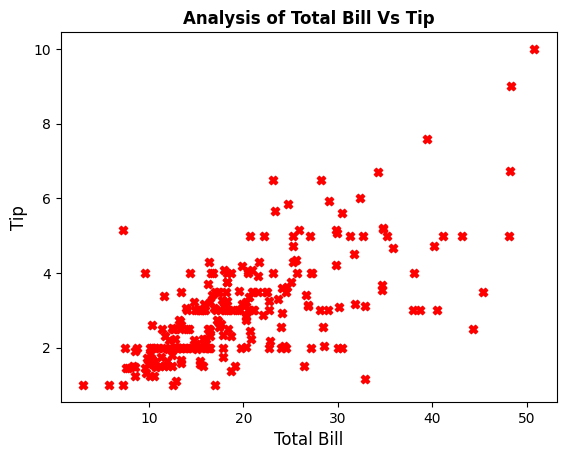

In [14]:
plt.scatter(tips["total_bill"], tips["tip"], color = "red", label = "Actual", marker = "X")
plt.title("Analysis of Total Bill Vs Tip", weight ="bold")
plt.xlabel("Total Bill", fontsize = 12)
plt.ylabel("Tip", fontsize = 12)
plt.show()

# Preparing data for Mahine Learning

In [24]:
# split into featue and target
X =  tips[["total_bill"]]
y = tips[["tip"]]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.40, random_state = 40)

# Building The Model

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [26]:
y_pred = model.predict(X_test)
y_pred

array([[2.93310151],
       [2.84274056],
       [2.11537965],
       [2.69333186],
       [2.1744274 ],
       [4.32967024],
       [2.32920408],
       [2.13864089],
       [1.93734174],
       [1.84698079],
       [3.69535427],
       [2.73806501],
       [3.21670964],
       [3.69356494],
       [2.34083469],
       [2.63070546],
       [2.3623066 ],
       [2.09927572],
       [2.68975321],
       [2.05006926],
       [3.32764783],
       [1.86755804],
       [5.03198059],
       [2.42224902],
       [2.8490032 ],
       [2.16100746],
       [2.94741612],
       [2.64859872],
       [4.5810705 ],
       [2.65844001],
       [2.37572655],
       [2.35246531],
       [5.72087099],
       [2.74164366],
       [2.51797794],
       [2.66559731],
       [2.47413946],
       [5.13844547],
       [3.43769136],
       [3.02614645],
       [3.2417602 ],
       [3.71951017],
       [3.46184726],
       [3.16392453],
       [2.71927709],
       [2.28715492],
       [2.43387963],
       [4.701

# Evaluation

In [41]:
print(f"Slope: {float(model.coef_[0]):.3f}")
print(f"Intercept: {model.intercept_[0]:.2f}")

Slope: 0.089
Intercept: 1.18


C:\Users\TEETOTECHNOLOGY\AppData\Local\Temp\ipykernel_18188\2897449663.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Slope: {float(model.coef_[0]):.3f}")


In [42]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

R2_score = r2_score(y_test, y_pred)

In [43]:
print(f"MSE: {mse: .3f}")
print(f"RMSE: {rmse: .3f}")
print(f"R2 Score: {R2_score: .3f}")

MSE:  1.344
RMSE:  1.159
R2 Score:  0.502


# Visualisation

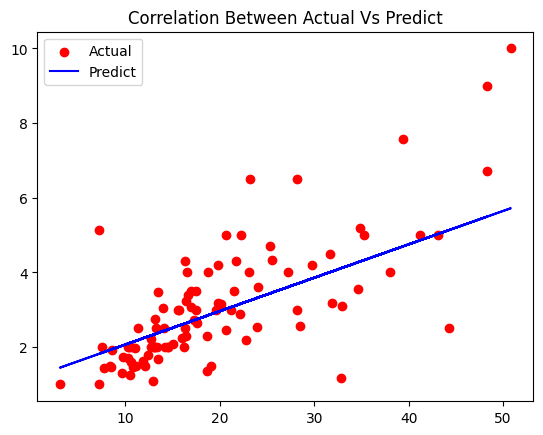

In [44]:
plt.scatter(X_test, y_test, color = "red", label = "Actual")
plt.plot(X_test, y_pred, color = "blue", label = "Predict")
plt.title("Correlation Between Actual Vs Predict")
plt.legend()
plt.show()

# Saving

In [45]:
joblib.dump(model, "tips.joblib")

['tips.joblib']

# Load Saved Model

In [46]:
loaded_model = joblib.load("tips.joblib")

In [53]:
X = [[20]]
predicted_tip = loaded_model.predict(X)
print(f"Tip Predcted: {float(predicted_tip[0]): .3f}")

Tip Predcted:  2.964


C:\Users\TEETOTECHNOLOGY\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
C:\Users\TEETOTECHNOLOGY\AppData\Local\Temp\ipykernel_18188\1822599194.py:3: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"Tip Predcted: {float(predicted_tip[0]): .3f}")
